# DBSCAN aplicado a turismo interno

**Idea central:** DBSCAN identifica regiones densas de viajes usando `noches_viaje` y `gasto_total_cop`. En lugar de pedir un número de grupos, recibe reglas de cercanía y densidad.

La preparación de los datos se realizó previamente en `01_preparacion_turismo.ipynb`.

# 1. ¿Qué problema resuelve DBSCAN?

DBSCAN es un algoritmo de **clustering no supervisado basado en densidad**. Agrupa observaciones que están suficientemente cerca y aparecen en regiones pobladas.

No recibe una variable objetivo ni un número de clusters. A partir de `eps`, `min_samples` y las distancias, determina los grupos que encuentra y los puntos que quedan como ruido.

> **Idea para recordar:** DBSCAN encuentra grupos porque encuentra densidad.

# 2. La intuición: densidad antes que centro

K-Means organiza los grupos alrededor de centroides. DBSCAN responde otra pregunta:

> **¿En qué zonas hay suficientes puntos suficientemente cerca?**

Para responderla necesita dos reglas:

- `eps`, el radio de la vecindad.
- `min_samples`, la cantidad mínima de puntos requerida para considerar una zona densa.

# 3. Conceptos fundamentales de DBSCAN

## 3.1 Vecindad

La vecindad de un punto `p` incluye los puntos que están a una distancia máxima `eps`.

$$N_{\varepsilon}(p)=\{q: dist(p,q)\leq\varepsilon\}$$

## 3.2 Punto núcleo

Un punto es núcleo si su vecindad contiene al menos `min_samples` observaciones. En `scikit-learn`, el propio punto cuenta dentro de esa vecindad.

$$|N_{\varepsilon}(p)|\geq min\_samples$$

## 3.3 Punto frontera

Un punto frontera no alcanza la densidad de núcleo, pero queda dentro de la vecindad de un núcleo. Por eso puede pertenecer a un cluster.

## 3.4 Ruido

Un punto que no puede conectarse a una región suficientemente densa se etiqueta como:

$$\boxed{-1}$$

Ruido no significa dato incorrecto, significa que con los parámetros elegidos no pertenece a una región densa.

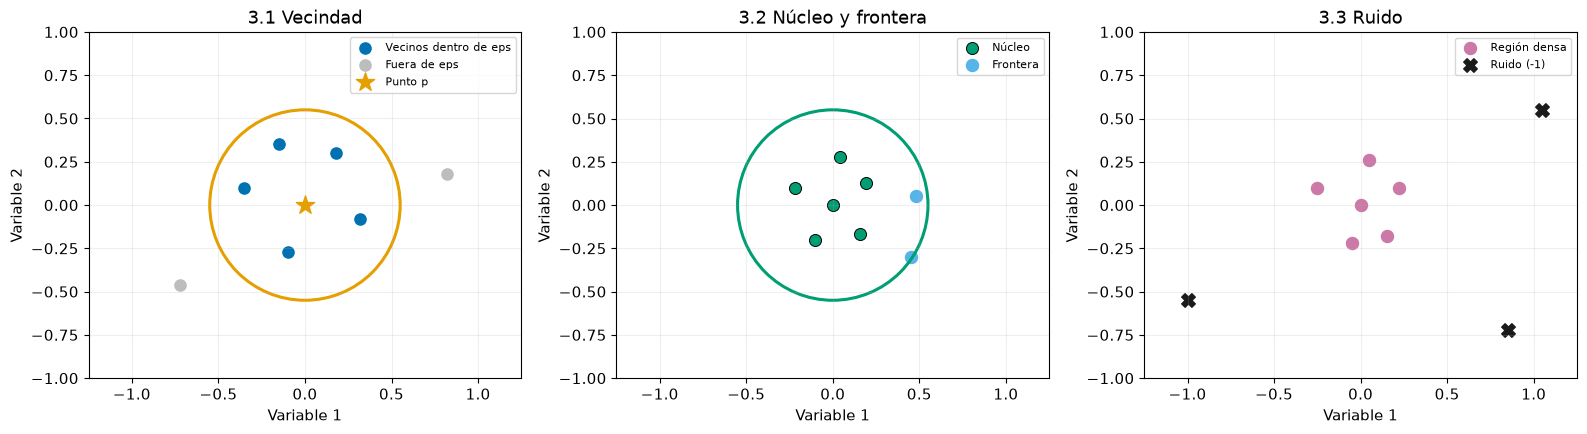

In [1]:
# Gráfico pedagógico, no pertenece a la base de turismo.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 11})

centro = np.array([0.0, 0.0])
dentro = np.array([[-0.35, 0.10], [-0.15, 0.35], [0.18, 0.30], [0.32, -0.08], [-0.10, -0.27]])
fuera = np.array([[0.82, 0.18], [-0.72, -0.46]])
eps_demo = 0.55

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
ax.scatter(dentro[:, 0], dentro[:, 1], s=65, color="#0072B2", label="Vecinos dentro de eps")
ax.scatter(fuera[:, 0], fuera[:, 1], s=65, color="#BDBDBD", label="Fuera de eps")
ax.scatter(*centro, s=190, marker="*", color="#E69F00", label="Punto p", zorder=3)
ax.add_patch(plt.Circle(centro, eps_demo, fill=False, linewidth=2.2, color="#E69F00"))
ax.set_title("3.1 Vecindad")
ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
nucleo = np.array([[0, 0], [-0.22, 0.10], [0.19, 0.13], [-0.10, -0.20], [0.16, -0.17], [0.04, 0.28]])
frontera = np.array([[0.48, 0.05], [0.45, -0.30]])
ax.scatter(nucleo[:, 0], nucleo[:, 1], s=75, color="#009E73", edgecolor="black", linewidth=0.7, label="Núcleo")
ax.scatter(frontera[:, 0], frontera[:, 1], s=75, color="#56B4E9", label="Frontera")
ax.add_patch(plt.Circle(centro, eps_demo, fill=False, linewidth=2.2, color="#009E73"))
ax.set_title("3.2 Núcleo y frontera")
ax.legend(fontsize=8, loc="upper right")

ax = axes[2]
grupo = np.array([[-0.25, 0.10], [0.0, 0.0], [0.22, 0.10], [-0.05, -0.22], [0.15, -0.18], [0.05, 0.26]])
ruido_demo = np.array([[1.05, 0.55], [-1.0, -0.55], [0.85, -0.72]])
ax.scatter(grupo[:, 0], grupo[:, 1], s=75, color="#CC79A7", label="Región densa")
ax.scatter(ruido_demo[:, 0], ruido_demo[:, 1], s=95, marker="X", color="#1A1A1A", label="Ruido (-1)")
ax.set_title("3.3 Ruido")
ax.legend(fontsize=8, loc="upper right")

for ax in axes:
    ax.set(xlim=(-1.25, 1.25), ylim=(-1.0, 1.0), xlabel="Variable 1", ylabel="Variable 2")
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 4. Cómo nace y se expande un cluster

En este ejemplo pedagógico hay cuatro puntos cercanos y uno aislado. Usamos `eps=0.15` y `min_samples=3`.

1. DBSCAN revisa la vecindad de un punto.
2. Si alcanza `min_samples`, ese punto es núcleo e inicia un cluster.
3. El cluster se expande hacia núcleos conectados y puntos frontera.
4. El punto aislado no logra conectarse y queda como ruido.

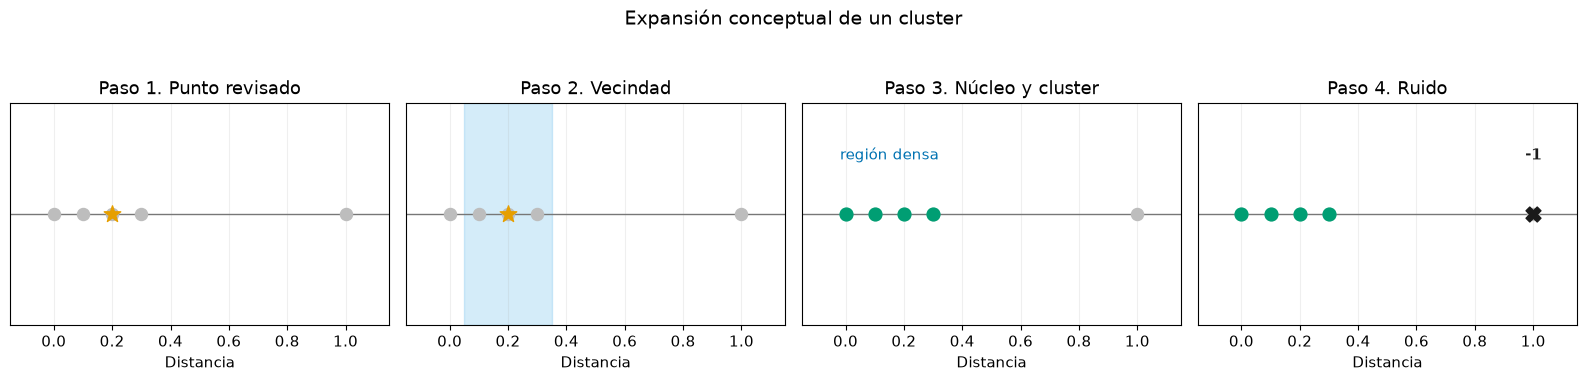

In [2]:
# Gráfico pedagógico en una dimensión, no pertenece a la base de turismo.
puntos_1d = np.array([0.00, 0.10, 0.20, 0.30, 1.00])
eps_1d = 0.15
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)

def base_1d(ax, titulo):
    ax.axhline(0, color="#777777", linewidth=1)
    ax.scatter(puntos_1d, np.zeros_like(puntos_1d), s=75, color="#BDBDBD", zorder=3)
    ax.set(title=titulo, xlim=(-0.15, 1.15), ylim=(-0.45, 0.45), xlabel="Distancia")
    ax.set_yticks([])
    ax.grid(axis="x", alpha=0.2)

base_1d(axes[0], "Paso 1. Punto revisado")
axes[0].scatter([0.20], [0], s=155, marker="*", color="#E69F00", zorder=4)

base_1d(axes[1], "Paso 2. Vecindad")
axes[1].axvspan(0.20-eps_1d, 0.20+eps_1d, color="#56B4E9", alpha=0.25)
axes[1].scatter([0.20], [0], s=155, marker="*", color="#E69F00", zorder=4)

base_1d(axes[2], "Paso 3. Núcleo y cluster")
axes[2].scatter(puntos_1d[:4], np.zeros(4), s=85, color="#009E73", zorder=4)
axes[2].text(0.15, 0.22, "región densa", ha="center", color="#0072B2")

base_1d(axes[3], "Paso 4. Ruido")
axes[3].scatter(puntos_1d[:4], np.zeros(4), s=85, color="#009E73", zorder=4)
axes[3].scatter([1.00], [0], s=115, marker="X", color="#1A1A1A", zorder=4)
axes[3].text(1.00, 0.22, "-1", ha="center", color="#1A1A1A", fontweight="bold")

fig.suptitle("Expansión conceptual de un cluster", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

# 5. ¿Por qué DBSCAN no necesita definir K?

En K-Means se indica un número de centroides, por ejemplo `n_clusters=3`.

DBSCAN no construye grupos alrededor de centros. Sus reglas son:

```text
¿Hay suficientes puntos cerca?
        ↓
Sí → región densa
        ↓
¿Hay otras regiones densas conectadas?
        ↓
Sí → expandir cluster
```

La cantidad de clusters aparece como resultado de la densidad observada y de los parámetros, no se entrega como un valor `K`.

# 6. Datos de turismo

Cada fila representa un viaje interno ya preparado. Se usan dos variables para poder visualizar los resultados:

- `noches_viaje`, número de noches del viaje.
- `gasto_total_cop`, gasto total del viaje en pesos colombianos.

Cada viaje es un punto en el plano `(noches, gasto)`.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 11})
pd.set_option("display.float_format", "{:,.2f}".format)

RUTA_DATOS = Path("datos_procesados/turismo_interno_dbscan.csv")
if not RUTA_DATOS.exists():
    raise FileNotFoundError(f"No se encontró la base preparada: {RUTA_DATOS}")

df = pd.read_csv(RUTA_DATOS)
variables = ["noches_viaje", "gasto_total_cop"]
display(df[variables].head())
print(f"Viajes disponibles: {len(df):,}")

,noches_viaje,gasto_total_cop
0,3,"150,000.00"
1,1,"60,000.00"
2,6,"2,000,000.00"
3,4,"2,000,000.00"
4,4,"2,000,000.00"


Viajes disponibles: 1,399


# 7. Antes de aplicar DBSCAN

En la nube original todavía no existen clusters, solo viajes. El eje de gasto se muestra en escala logarítmica para visualizar a la vez gastos pequeños y grandes, sin modificar los datos.

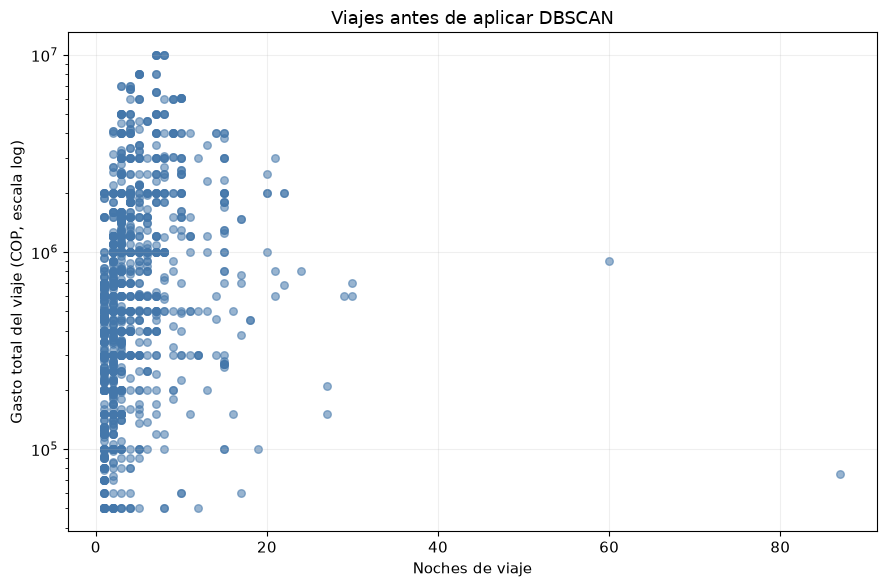

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df["noches_viaje"], df["gasto_total_cop"], s=30, alpha=0.55, color="#4477AA")
ax.set_yscale("log")
ax.set(title="Viajes antes de aplicar DBSCAN", xlabel="Noches de viaje", ylabel="Gasto total del viaje (COP, escala log)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 8. ¿Por qué transformar y escalar?

DBSCAN usa distancias. `noches_viaje` está medida en unidades y `gasto_total_cop` en pesos, por lo que sus escalas originales no son comparables.

## 1. `log1p`

Aplicamos $x'=\log(1+x)$. Esta transformación comprime valores muy altos de gasto y suaviza la asimetría de la distribución, sin perder el orden de los viajes.

## 2. `StandardScaler`

Aplicamos $z=(x-\mu)/\sigma$. Cada variable queda centrada alrededor de 0 y con una dispersión comparable. Así, una diferencia de gasto no domina automáticamente una distancia solo porque está expresada en pesos.

> `eps` se interpreta en esta escala transformada y estandarizada, no en pesos ni en noches originales.

La base original no cambia. DBSCAN recibe la matriz transformada y escalada.

In [5]:
df_modelo = df.copy()
df_modelo["log_noches"] = np.log1p(df_modelo["noches_viaje"])
df_modelo["log_gasto"] = np.log1p(df_modelo["gasto_total_cop"])

escalador = StandardScaler()
X_escalado = escalador.fit_transform(df_modelo[["log_noches", "log_gasto"]])

df_modelo["noches_escaladas"] = X_escalado[:, 0]
df_modelo["gasto_escalado"] = X_escalado[:, 1]

print("Matriz que recibe DBSCAN:", X_escalado.shape)
display(df_modelo[["noches_viaje", "gasto_total_cop", "noches_escaladas", "gasto_escalado"]].head())

Matriz que recibe DBSCAN: (1399, 2)


,noches_viaje,gasto_total_cop,noches_escaladas,gasto_escalado
0,3,"150,000.00",-0.08,-1.15
1,1,"60,000.00",-1.22,-1.93
2,6,"2,000,000.00",0.84,1.06
3,4,"2,000,000.00",0.29,1.06
4,4,"2,000,000.00",0.29,1.06


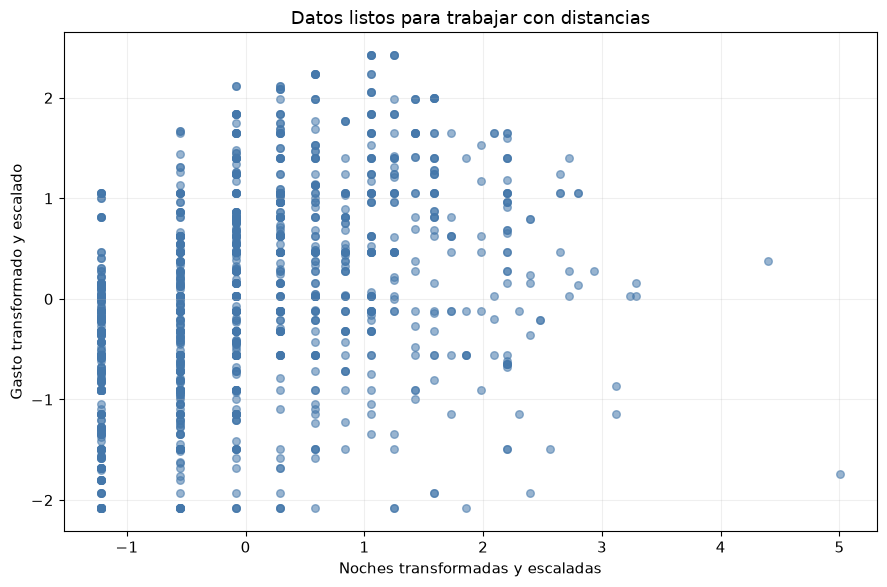

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_escalado[:, 0], X_escalado[:, 1], s=30, alpha=0.55, color="#4477AA")
ax.set(title="Datos listos para trabajar con distancias", xlabel="Noches transformadas y escaladas", ylabel="Gasto transformado y escalado")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 9. Los dos parámetros que controlan DBSCAN

## `eps`

Es el radio de la vecindad. Si es pequeño, cuesta conectar puntos y puede aumentar el ruido. Si es grande, se conectan más regiones y algunos grupos pueden unirse.

## `min_samples`

Es la cantidad mínima de puntos para considerar que una zona es suficientemente densa. Al aumentarlo, la condición es más estricta y menos puntos pueden ser núcleo.

> `eps` responde **qué tan cerca**, `min_samples` responde **cuántos puntos necesito**.

# 10. Criterio previo, gráfico K-distance

Para proponer `eps`, se calcula para cada punto la distancia hasta su vecino número `min_samples`. En las zonas densas esas distancias suelen ser pequeñas, mientras que para observaciones más aisladas aumentan.

Con `min_samples=8`, el cambio de pendiente orienta `eps=0.30` como candidato para la demostración. No es una respuesta automática, después se valida con los experimentos.

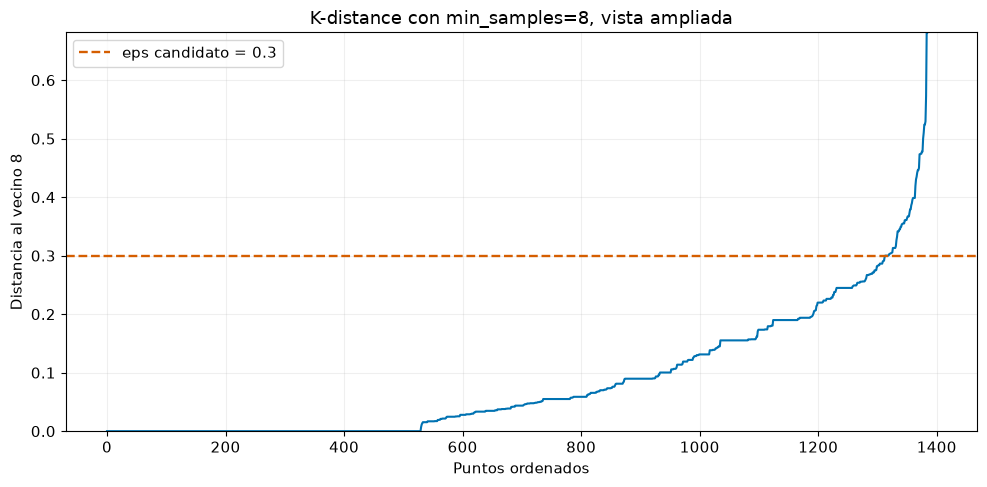

In [7]:
min_samples_kdist = 8
eps_candidato = 0.30

vecinos = NearestNeighbors(n_neighbors=min_samples_kdist)
distancias, _ = vecinos.fit(X_escalado).kneighbors(X_escalado)
k_distances = np.sort(distancias[:, -1])
limite_visual = np.quantile(k_distances, 0.99)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, linewidth=1.5, color="#0072B2")
ax.axhline(eps_candidato, color="#D55E00", linestyle="--", linewidth=1.7, label=f"eps candidato = {eps_candidato}")
ax.set_ylim(0, limite_visual)
ax.set(title=f"K-distance con min_samples={min_samples_kdist}, vista ampliada", xlabel="Puntos ordenados", ylabel=f"Distancia al vecino {min_samples_kdist}")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

### ¿Por qué `eps=0.30` es un candidato?

En la parte inicial de la curva, las distancias corresponden principalmente a zonas densas y son pequeñas. Cerca de `0.30` aparece el cambio entre esa zona y el crecimiento más rápido asociado a puntos menos conectados.

Por eso se propone `0.30` como un punto de partida. No es una elección automática, se contrasta en los experimentos de `eps` y `min_samples`.

# 11. ¿Qué recibe y qué devuelve `DBSCAN`?

```python
modelo = DBSCAN(eps=0.30, min_samples=8)
etiquetas = modelo.fit_predict(X_escalado)
```

`DBSCAN(...)` crea el algoritmo con las reglas de vecindad y densidad. `fit_predict(...)` analiza la matriz de distancias y devuelve una etiqueta por viaje.

```text
[0, 0, 0, 1, 1, -1, 2, 2, ...]
```

Las etiquetas `0`, `1`, `2` representan clusters y `-1` representa ruido. DBSCAN no devuelve centroides.

In [8]:
COLORES_CLUSTERS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]

def ajustar_dbscan(X, eps, min_samples):
    modelo = DBSCAN(eps=eps, min_samples=min_samples)
    etiquetas = modelo.fit_predict(X)
    return modelo, etiquetas

def resumen_dbscan(etiquetas, eps, min_samples):
    n_clusters = len(set(etiquetas)) - int(-1 in etiquetas)
    n_ruido = int((etiquetas == -1).sum())
    return {
        "eps": eps,
        "min_samples": min_samples,
        "clusters": n_clusters,
        "ruido": n_ruido,
        "ruido (%)": round(n_ruido / len(etiquetas) * 100, 2),
    }

def graficar_dbscan(ax, X, etiquetas, titulo):
    for etiqueta in sorted(set(etiquetas)):
        mascara = etiquetas == etiqueta
        if etiqueta == -1:
            ax.scatter(X[mascara, 0], X[mascara, 1], s=46, alpha=0.95, color="#1A1A1A", marker="X", label="Ruido (-1)")
        else:
            color = COLORES_CLUSTERS[etiqueta % len(COLORES_CLUSTERS)]
            ax.scatter(X[mascara, 0], X[mascara, 1], s=28, alpha=0.74, color=color, marker="o", label=f"Cluster {etiqueta}")
    ax.set(title=titulo, xlabel="Noches transformadas y escaladas", ylabel="Gasto transformado y escalado")
    ax.grid(alpha=0.2)

# 12. Primera ejecución

Se usa la configuración candidata `eps=0.30` y `min_samples=8`.

DBSCAN primero identifica vecindades, después determina cuáles tienen suficiente densidad y finalmente expande las regiones densas conectadas. Los puntos que no logran conectarse quedan con la etiqueta `-1`.

,eps,min_samples,clusters,ruido,ruido (%)
0,0.30,8,6,50,3.57


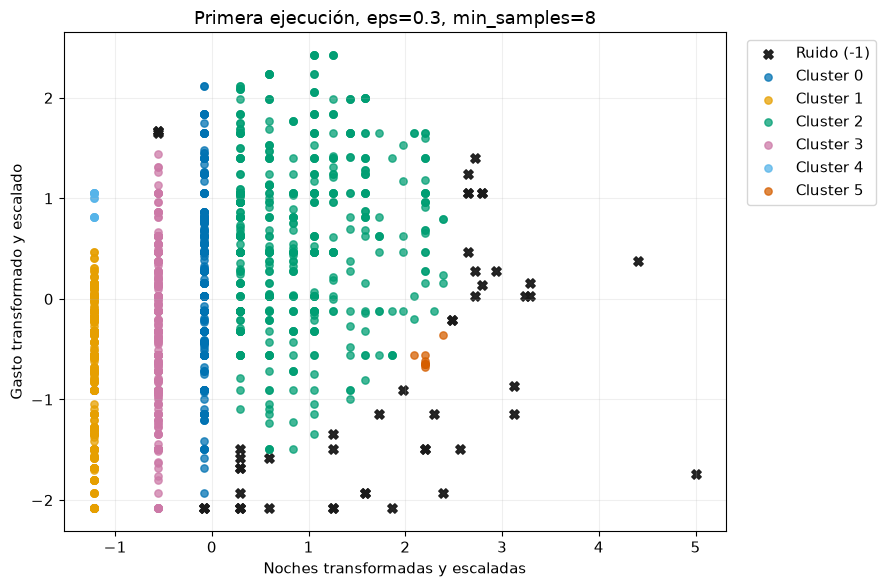

In [9]:
eps_inicial = eps_candidato
min_samples_inicial = 8
modelo_inicial, etiquetas_iniciales = ajustar_dbscan(X_escalado, eps_inicial, min_samples_inicial)

display(pd.DataFrame([resumen_dbscan(etiquetas_iniciales, eps_inicial, min_samples_inicial)]))

fig, ax = plt.subplots(figsize=(9, 6))
graficar_dbscan(ax, X_escalado, etiquetas_iniciales, f"Primera ejecución, eps={eps_inicial}, min_samples={min_samples_inicial}")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 13. Experimento 1, cambiar `eps`

Se mantiene `min_samples=8` y se comparan tres radios de vecindad. La pregunta visual es: **¿qué nuevas conexiones aparecen cuando aumenta `eps`?**

La fila superior usa los viajes reales. La fila inferior conserva el mismo ejemplo pequeño en las tres columnas y dibuja el radio de `eps` alrededor de una estrella. Allí se mantiene `min_samples=4` solo para que el mecanismo sea fácil de ver con pocos puntos.

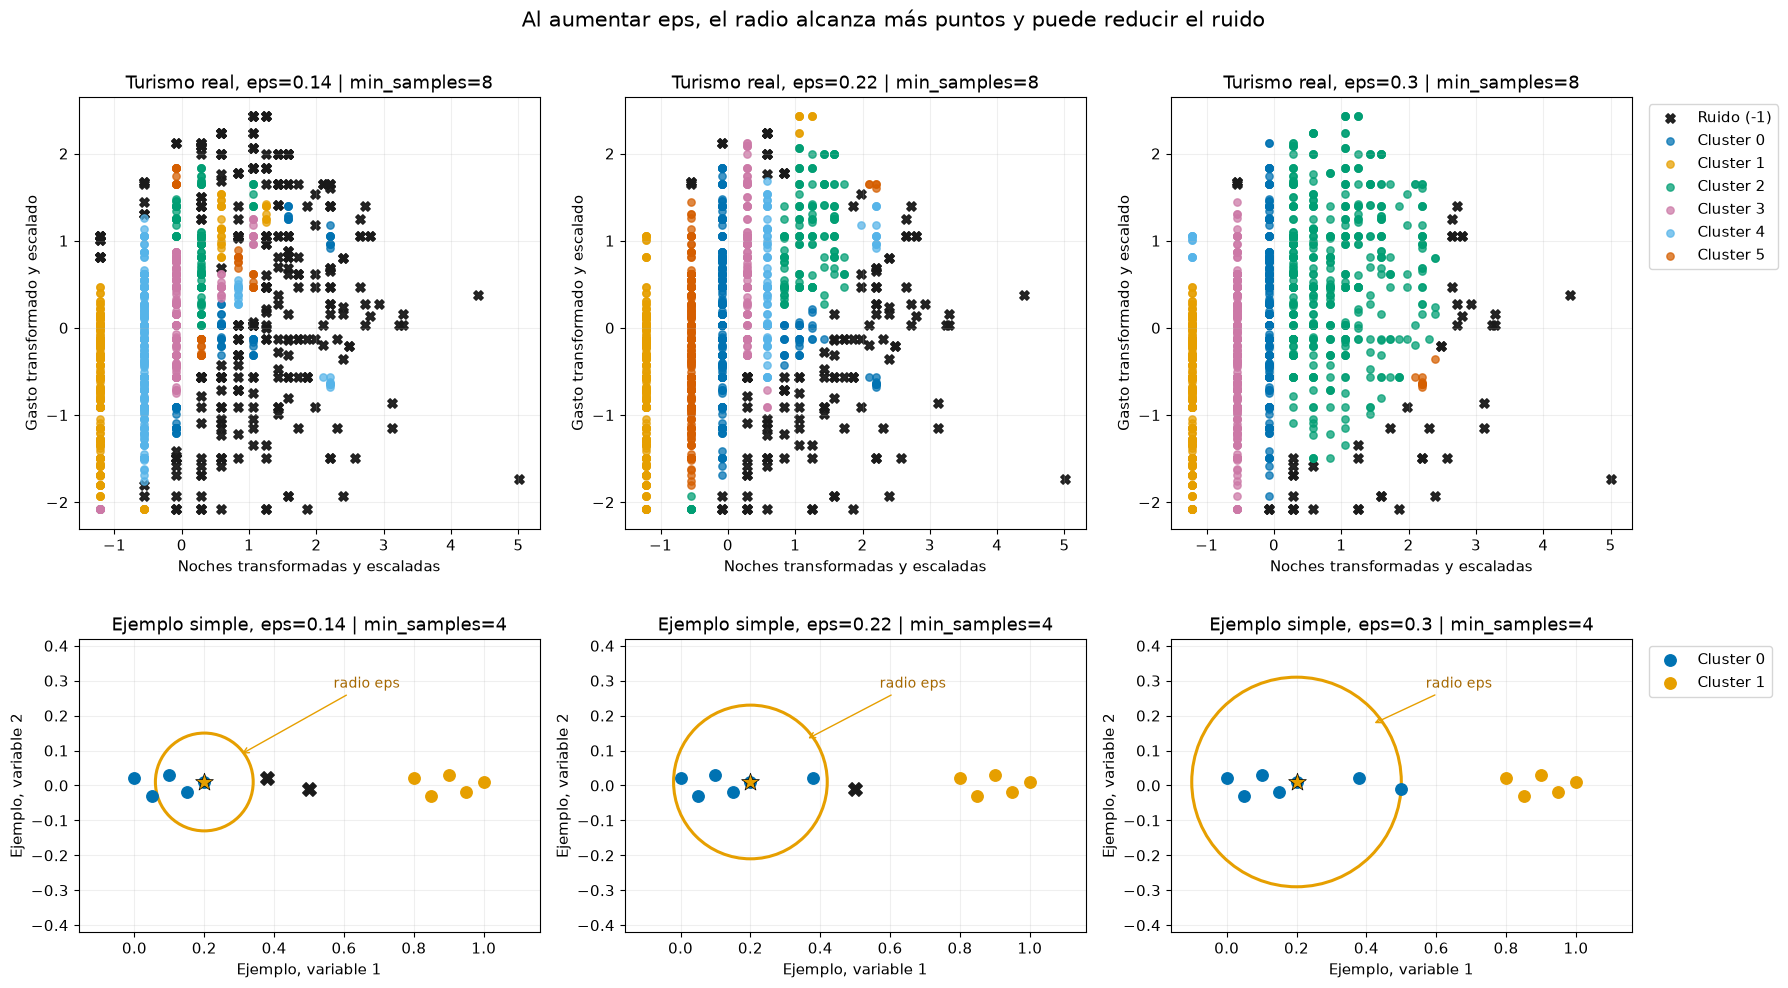

,eps,min_samples,clusters,ruido,ruido (%)
0,0.14,8,26,302,21.59
1,0.22,8,14,137,9.79
2,0.30,8,6,50,3.57


In [10]:
min_samples_fijo = 8
valores_eps = [0.14, 0.22, 0.30]

# Mismo escenario simple en los tres paneles inferiores.
# Se usa min_samples=4 para que el mecanismo sea visible con pocos puntos.
X_simple = np.array([
    [0.00, 0.02], [0.05, -0.03], [0.10, 0.03], [0.15, -0.02], [0.20, 0.01],
    [0.38, 0.02], [0.50, -0.01],
    [0.80, 0.02], [0.85, -0.03], [0.90, 0.03], [0.95, -0.02], [1.00, 0.01],
])
punto_referencia = X_simple[4]
min_samples_simple = 4

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
resumen_eps = []

for columna, eps in enumerate(valores_eps):
    # Fila superior: resultado real con turismo.
    ax_real = axes[0, columna]
    _, etiquetas = ajustar_dbscan(X_escalado, eps=eps, min_samples=min_samples_fijo)
    graficar_dbscan(ax_real, X_escalado, etiquetas, f"Turismo real, eps={eps} | min_samples={min_samples_fijo}")
    resumen_eps.append(resumen_dbscan(etiquetas, eps, min_samples_fijo))

    # Fila inferior: mismo principio con pocos puntos y radio eps visible.
    ax_simple = axes[1, columna]
    etiquetas_simple = DBSCAN(eps=eps, min_samples=min_samples_simple).fit_predict(X_simple)

    for etiqueta in sorted(set(etiquetas_simple)):
        mascara = etiquetas_simple == etiqueta
        if etiqueta == -1:
            ax_simple.scatter(X_simple[mascara, 0], X_simple[mascara, 1], s=95, marker="X", color="#1A1A1A", label="Ruido (-1)", zorder=4)
        else:
            color = COLORES_CLUSTERS[etiqueta % len(COLORES_CLUSTERS)]
            ax_simple.scatter(X_simple[mascara, 0], X_simple[mascara, 1], s=68, color=color, label=f"Cluster {etiqueta}", zorder=3)

    ax_simple.scatter(*punto_referencia, s=180, marker="*", color="#E69F00", edgecolor="black", linewidth=0.5, zorder=5)
    ax_simple.add_patch(plt.Circle(punto_referencia, eps, fill=False, color="#E69F00", linewidth=2.2, zorder=2))
    ax_simple.annotate("radio eps", xy=(punto_referencia[0] + eps * 0.72, punto_referencia[1] + eps * 0.55), xytext=(0.57, 0.28), arrowprops={"arrowstyle": "->", "color": "#E69F00"}, color="#A56700", fontsize=10)
    ax_simple.set(title=f"Ejemplo simple, eps={eps} | min_samples={min_samples_simple}", xlabel="Ejemplo, variable 1", ylabel="Ejemplo, variable 2", xlim=(-0.16, 1.16), ylim=(-0.42, 0.42))
    ax_simple.grid(alpha=0.2)
    ax_simple.set_aspect("equal", adjustable="box")

axes[0, -1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1, -1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Al aumentar eps, el radio alcanza más puntos y puede reducir el ruido", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()
display(pd.DataFrame(resumen_eps))

### Lectura de la gráfica

Al aumentar `eps`, una vecindad puede alcanzar puntos que antes estaban fuera. Esto puede reducir ruido, ampliar clusters o conectar regiones que antes estaban separadas.

El objetivo no es escoger el `eps` más grande, sino un radio que represente razonablemente qué significa estar cerca en estos datos.

# 14. Experimento 2, cambiar `min_samples`

Se conserva `eps=0.30`, el valor candidato del K-distance, y se modifica la exigencia de densidad. Al aumentar `min_samples`, se requieren más vecinos para que un punto sea núcleo.

La fila superior usa los viajes reales. La fila inferior conserva el mismo ejemplo pequeño con un `eps` fijo, así se observa qué grupos dejan de alcanzar la cantidad de vecinos exigida.

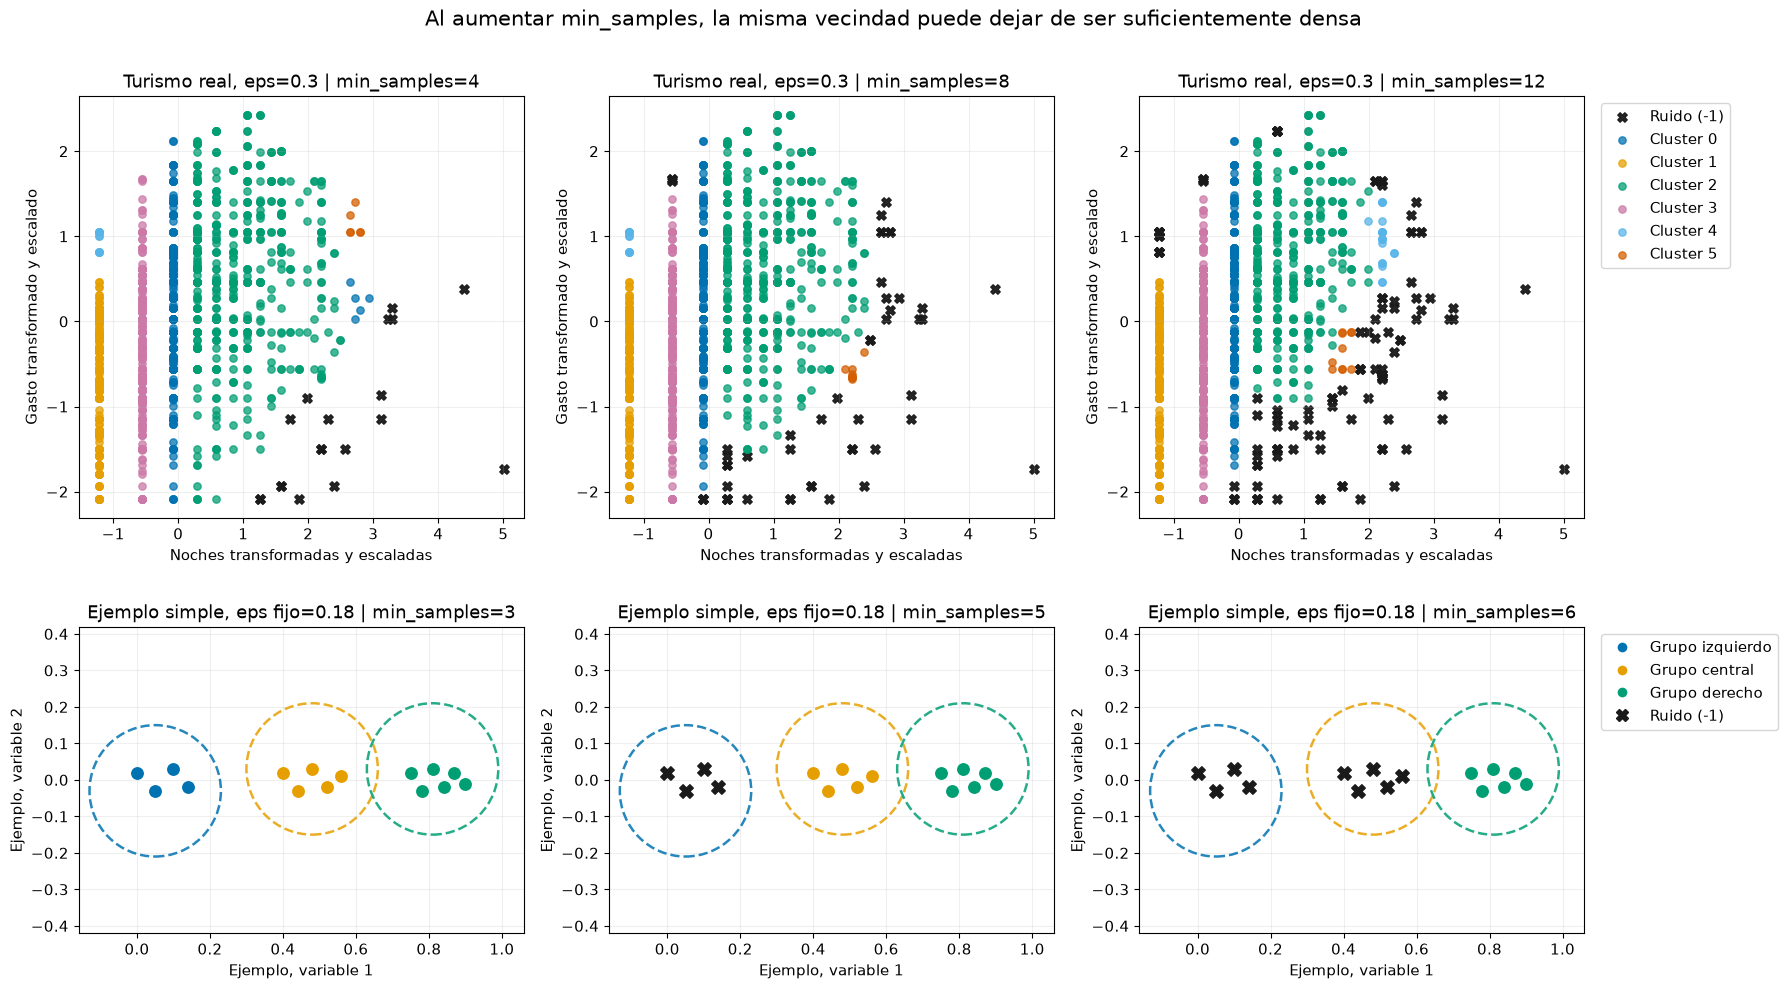

,eps,min_samples,clusters,ruido,ruido (%)
0,0.30,4,7,19,1.36
1,0.30,8,6,50,3.57
2,0.30,12,6,112,8.01


In [11]:
eps_fijo = eps_candidato
valores_min_samples = [4, 8, 12]

# Mismo escenario pequeño en los tres paneles inferiores.
# eps se mantiene fijo, cambian solamente los vecinos exigidos.
X_simple_min = np.array([
    [0.00, 0.02], [0.05, -0.03], [0.10, 0.03], [0.14, -0.02],
    [0.40, 0.02], [0.44, -0.03], [0.48, 0.03], [0.52, -0.02], [0.56, 0.01],
    [0.75, 0.02], [0.78, -0.03], [0.81, 0.03], [0.84, -0.02], [0.87, 0.02], [0.90, -0.01],
])
eps_simple_fijo = 0.18
valores_min_samples_simple = [3, 5, 6]

# La identidad visual se mantiene estable entre las tres columnas.
grupos_simple = [
    {"nombre": "Grupo izquierdo", "indices": np.arange(0, 4), "referencia": 1, "color": "#0072B2"},
    {"nombre": "Grupo central", "indices": np.arange(4, 9), "referencia": 6, "color": "#E69F00"},
    {"nombre": "Grupo derecho", "indices": np.arange(9, 15), "referencia": 11, "color": "#009E73"},
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
resumen_min_samples = []

for columna, (min_samples, min_samples_simple) in enumerate(zip(valores_min_samples, valores_min_samples_simple)):
    # Fila superior: resultado real con turismo.
    ax_real = axes[0, columna]
    _, etiquetas = ajustar_dbscan(X_escalado, eps=eps_fijo, min_samples=min_samples)
    graficar_dbscan(ax_real, X_escalado, etiquetas, f"Turismo real, eps={eps_fijo} | min_samples={min_samples}")
    resumen_min_samples.append(resumen_dbscan(etiquetas, eps_fijo, min_samples))

    # Fila inferior: eps fijo, solo cambia la exigencia de densidad.
    ax_simple = axes[1, columna]
    etiquetas_simple = DBSCAN(eps=eps_simple_fijo, min_samples=min_samples_simple).fit_predict(X_simple_min)

    for grupo in grupos_simple:
        indices = grupo["indices"]
        etiqueta_grupo = etiquetas_simple[indices[0]]
        if etiqueta_grupo == -1:
            ax_simple.scatter(X_simple_min[indices, 0], X_simple_min[indices, 1], s=95, marker="X", color="#1A1A1A", zorder=4)
        else:
            ax_simple.scatter(X_simple_min[indices, 0], X_simple_min[indices, 1], s=68, color=grupo["color"], zorder=3)

        punto_referencia = X_simple_min[grupo["referencia"]]
        ax_simple.add_patch(plt.Circle(punto_referencia, eps_simple_fijo, fill=False, color=grupo["color"], linestyle="--", linewidth=1.8, alpha=0.85, zorder=2))
    ax_simple.set(title=f"Ejemplo simple, eps fijo={eps_simple_fijo} | min_samples={min_samples_simple}", xlabel="Ejemplo, variable 1", ylabel="Ejemplo, variable 2", xlim=(-0.16, 1.06), ylim=(-0.42, 0.42))
    ax_simple.grid(alpha=0.2)
    ax_simple.set_aspect("equal", adjustable="box")

axes[0, -1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
leyenda_simple = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=grupo["color"], markersize=8, label=grupo["nombre"])
    for grupo in grupos_simple
] + [Line2D([0], [0], marker="X", color="#1A1A1A", linestyle="", markersize=8, label="Ruido (-1)")]
axes[1, -1].legend(handles=leyenda_simple, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Al aumentar min_samples, la misma vecindad puede dejar de ser suficientemente densa", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()
display(pd.DataFrame(resumen_min_samples))

### Lectura de la gráfica

Al aumentar `min_samples`, se vuelve más estricta la definición de densidad. Un punto que antes era núcleo puede dejar de serlo, algunas regiones dejan de expandirse y puede aumentar el ruido.

La pregunta útil es: **¿qué ocurre cuando exigimos cada vez más puntos para considerar una zona suficientemente densa?**

# 15. Interacción entre `eps` y `min_samples`

Los parámetros se interpretan juntos. Un `eps` bajo con un `min_samples` alto es una condición estricta, mientras que un `eps` alto con un `min_samples` bajo facilita conectar puntos.

Las cuatro gráficas superiores usan turismo real. Las cuatro inferiores usan el mismo ejemplo pequeño, con tres regiones de tamaños distintos y puntos aislados, para aislar visualmente las mismas cuatro combinaciones de parámetros.

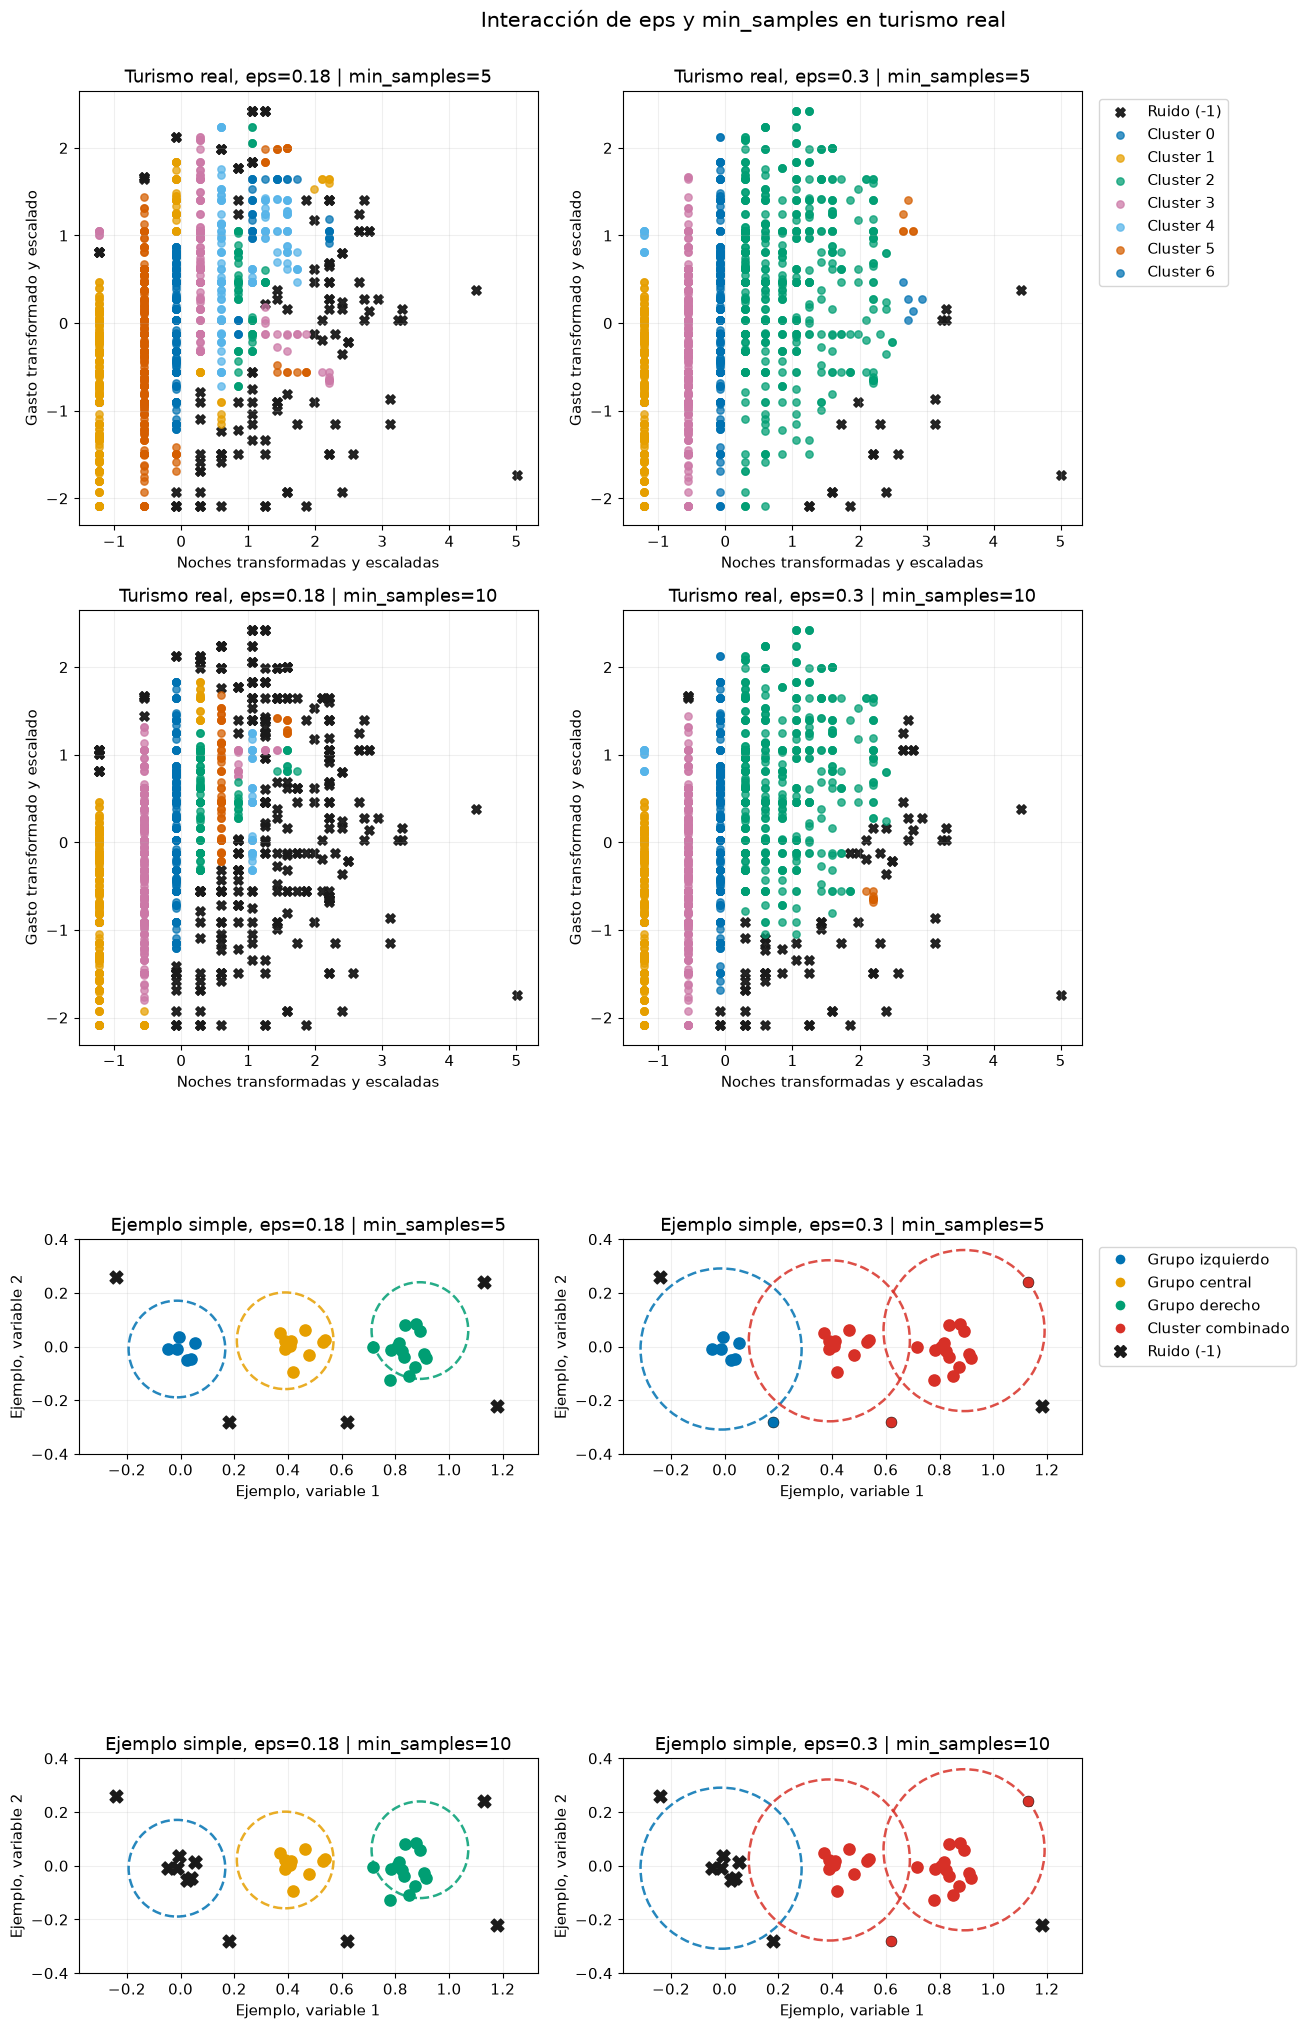

,eps,min_samples,clusters,ruido,ruido (%)
0,0.18,5,27,125,8.93
1,0.30,5,7,19,1.36
2,0.18,10,18,292,20.87
3,0.30,10,6,74,5.29


In [12]:
combinaciones = [(0.18, 5), (0.30, 5), (0.18, 10), (0.30, 10)]

# El ejemplo inferior conserva tres regiones de tamaños 6, 10 y 14.
# Así se pueden ver separadamente los efectos de eps y min_samples.
rng_simple = np.random.default_rng(24)
grupo_izquierdo = np.array([0.00, 0.00]) + rng_simple.normal(0, 0.04, size=(6, 2))
grupo_central = np.array([0.45, 0.00]) + rng_simple.normal(0, 0.045, size=(10, 2))
grupo_derecho = np.array([0.85, 0.00]) + rng_simple.normal(0, 0.05, size=(14, 2))
puntos_aislados = np.array([[-0.24, 0.26], [0.18, -0.28], [0.62, -0.28], [1.13, 0.24], [1.18, -0.22]])
X_simple_interaccion = np.vstack([grupo_izquierdo, grupo_central, grupo_derecho, puntos_aislados])
grupos_interaccion = [
    {"nombre": "Grupo izquierdo", "indices": np.arange(0, 6), "referencia": 2, "color": "#0072B2"},
    {"nombre": "Grupo central", "indices": np.arange(6, 16), "referencia": 10, "color": "#E69F00"},
    {"nombre": "Grupo derecho", "indices": np.arange(16, 30), "referencia": 22, "color": "#009E73"},
]
indices_aislados = np.arange(30, 35)
combinaciones_simple = [(0.18, 5), (0.30, 5), (0.18, 10), (0.30, 10)]

fig, axes = plt.subplots(4, 2, figsize=(15, 21))
axes_reales = axes[:2, :].flat
axes_simples = axes[2:, :].flat
resumen_interaccion = []

for ax, (eps, min_samples) in zip(axes_reales, combinaciones):
    _, etiquetas = ajustar_dbscan(X_escalado, eps=eps, min_samples=min_samples)
    graficar_dbscan(ax, X_escalado, etiquetas, f"Turismo real, eps={eps} | min_samples={min_samples}")
    resumen_interaccion.append(resumen_dbscan(etiquetas, eps, min_samples))

for ax, (eps_simple, min_samples_simple) in zip(axes_simples, combinaciones_simple):
    etiquetas_simple = DBSCAN(eps=eps_simple, min_samples=min_samples_simple).fit_predict(X_simple_interaccion)

    etiquetas_grupo = [etiquetas_simple[grupo["indices"][0]] for grupo in grupos_interaccion]
    etiquetas_activas = [etiqueta for etiqueta in etiquetas_grupo if etiqueta != -1]

    for grupo, etiqueta_grupo in zip(grupos_interaccion, etiquetas_grupo):
        indices = grupo["indices"]
        if etiqueta_grupo == -1:
            ax.scatter(X_simple_interaccion[indices, 0], X_simple_interaccion[indices, 1], s=90, marker="X", color="#1A1A1A", zorder=4)
        else:
            color_puntos = "#D73027" if etiquetas_activas.count(etiqueta_grupo) > 1 else grupo["color"]
            ax.scatter(X_simple_interaccion[indices, 0], X_simple_interaccion[indices, 1], s=65, color=color_puntos, zorder=3)

        punto_referencia = X_simple_interaccion[grupo["referencia"]]
        color_circulo = "#D73027" if etiqueta_grupo != -1 and etiquetas_activas.count(etiqueta_grupo) > 1 else grupo["color"]
        ax.add_patch(plt.Circle(punto_referencia, eps_simple, fill=False, color=color_circulo, linestyle="--", linewidth=1.8, alpha=0.85, zorder=2))

    # Los puntos aislados pueden permanecer como ruido o conectarse al ampliar eps.
    etiqueta_izquierda, etiqueta_central, etiqueta_derecha = etiquetas_grupo
    for indice in indices_aislados:
        etiqueta = etiquetas_simple[indice]
        if etiqueta == -1:
            ax.scatter(*X_simple_interaccion[indice], s=85, marker="X", color="#1A1A1A", zorder=4)
        else:
            if etiqueta == etiqueta_izquierda:
                color_aislado = "#0072B2"
            elif etiqueta == etiqueta_central and etiqueta_central == etiqueta_derecha:
                color_aislado = "#D73027"
            elif etiqueta == etiqueta_central:
                color_aislado = "#E69F00"
            else:
                color_aislado = "#009E73"
            ax.scatter(*X_simple_interaccion[indice], s=62, color=color_aislado, edgecolor="black", linewidth=0.35, zorder=4)

    ax.set(title=f"Ejemplo simple, eps={eps_simple} | min_samples={min_samples_simple}", xlabel="Ejemplo, variable 1", ylabel="Ejemplo, variable 2", xlim=(-0.38, 1.33), ylim=(-0.40, 0.40))
    ax.grid(alpha=0.2)
    ax.set_aspect("equal", adjustable="box")

axes[0, 1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
leyenda_simple = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=grupo["color"], markersize=8, label=grupo["nombre"])
    for grupo in grupos_interaccion
] + [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#D73027", markersize=8, label="Cluster combinado"),
    Line2D([0], [0], marker="X", color="#1A1A1A", linestyle="", markersize=8, label="Ruido (-1)"),
]
axes[2, 1].legend(handles=leyenda_simple, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.text(0.5, 0.987, "Interacción de eps y min_samples en turismo real", ha="center", fontsize=15)
plt.tight_layout(rect=[0, 0, 0.88, 0.975])
plt.show()
display(pd.DataFrame(resumen_interaccion))

### Cómo leer la interacción

| `eps` | `min_samples` | Lectura visual |
|---|---:|---|
| bajo | bajo | las regiones pueden mantenerse separadas y se exige poca densidad |
| alto | bajo | se facilita conectar regiones y absorber puntos cercanos |
| bajo | alto | la condición es estricta, pueden aparecer más puntos de ruido |
| alto | alto | el radio conecta más, pero la densidad exigida evita formar grupos débiles |

El color rojo representa un **cluster combinado** en el ejemplo simple. No es un cuarto grupo ni una modificación de los datos: al aumentar `eps`, las regiones central y derecha quedan conectadas por densidad y DBSCAN les asigna una sola etiqueta.

## ¿Qué busca el analista al ajustar DBSCAN?

No busca maximizar la cantidad de clusters ni minimizar el ruido a cualquier costo. Busca una estructura de densidad estable e interpretable para el problema: sin unir regiones distintas artificialmente, sin fragmentar una región clara y entendiendo si el ruido tiene sentido como observaciones poco frecuentes.

# 16. Configuración de demostración y tipos de punto

Se cierra con `eps=0.30` y `min_samples=8`. Es una configuración de demostración apoyada por el K-distance y los experimentos, no una combinación universal.

La siguiente visualización diferencia núcleo, frontera y ruido. El color mantiene la pertenencia al cluster, el borde negro identifica puntos núcleo y la `X` negra identifica ruido.

In [13]:
eps_final = eps_candidato
min_samples_final = 8
modelo_final, etiquetas_finales = ajustar_dbscan(X_escalado, eps_final, min_samples_final)
display(pd.DataFrame([resumen_dbscan(etiquetas_finales, eps_final, min_samples_final)]))

es_nucleo = np.zeros(len(etiquetas_finales), dtype=bool)
es_nucleo[modelo_final.core_sample_indices_] = True

df_resultado = df_modelo.copy()
df_resultado["cluster"] = etiquetas_finales
df_resultado["tipo_punto"] = np.select(
    [etiquetas_finales == -1, es_nucleo],
    ["Ruido", "Núcleo"],
    default="Frontera",
)

,eps,min_samples,clusters,ruido,ruido (%)
0,0.30,8,6,50,3.57


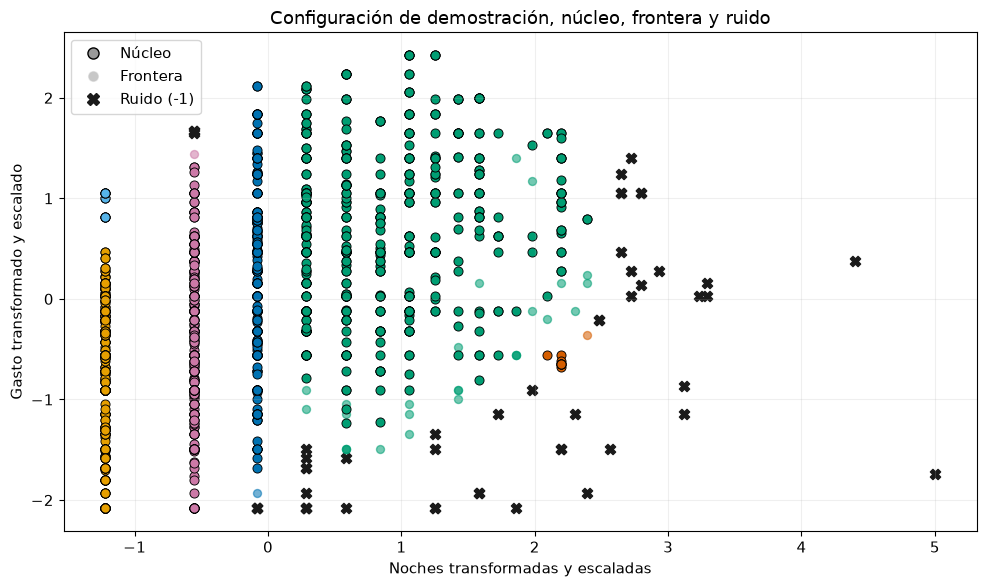

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

for etiqueta in sorted(set(etiquetas_finales)):
    mascara_cluster = etiquetas_finales == etiqueta
    if etiqueta == -1:
        ax.scatter(X_escalado[mascara_cluster, 0], X_escalado[mascara_cluster, 1], s=54, marker="X", color="#1A1A1A", label="Ruido (-1)")
    else:
        color = COLORES_CLUSTERS[etiqueta % len(COLORES_CLUSTERS)]
        mascara_nucleo = mascara_cluster & es_nucleo
        mascara_frontera = mascara_cluster & ~es_nucleo
        ax.scatter(X_escalado[mascara_frontera, 0], X_escalado[mascara_frontera, 1], s=33, color=color, alpha=0.55)
        ax.scatter(X_escalado[mascara_nucleo, 0], X_escalado[mascara_nucleo, 1], s=43, color=color, edgecolor="black", linewidth=0.65)

leyenda_tipo = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#999999", markeredgecolor="black", markersize=8, label="Núcleo"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#999999", markersize=8, alpha=0.55, label="Frontera"),
    Line2D([0], [0], marker="X", color="#1A1A1A", linestyle="", markersize=8, label="Ruido (-1)"),
]
ax.legend(handles=leyenda_tipo, loc="upper left")
ax.set(title="Configuración de demostración, núcleo, frontera y ruido", xlabel="Noches transformadas y escaladas", ylabel="Gasto transformado y escalado")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 17. Ruido y resumen de los clusters

Un viaje con etiqueta `-1` no es necesariamente un error. Significa que no se conectó a una región suficientemente densa con los parámetros usados.

La tabla siguiente resume los grupos encontrados sin asignarles interpretaciones causales.

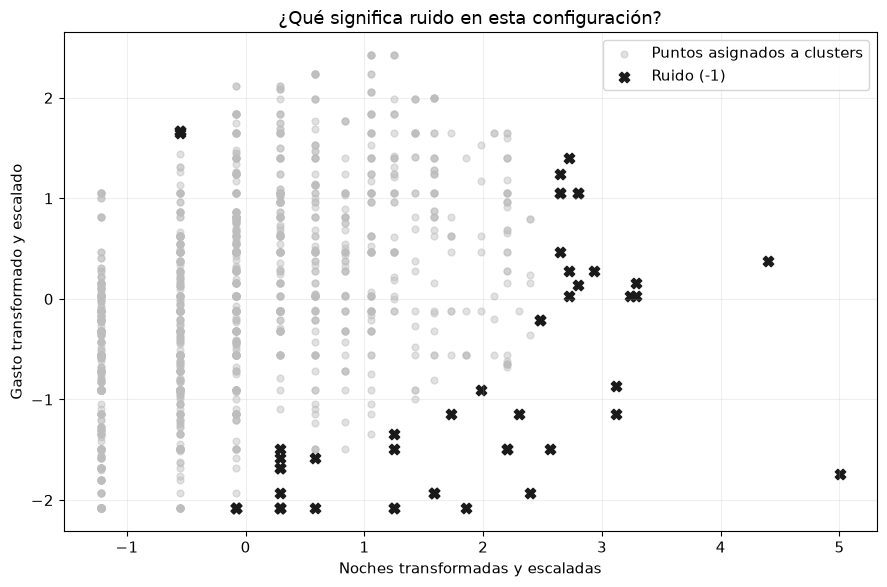

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
mascara_ruido = etiquetas_finales == -1
ax.scatter(X_escalado[~mascara_ruido, 0], X_escalado[~mascara_ruido, 1], s=24, color="#BDBDBD", alpha=0.45, label="Puntos asignados a clusters")
ax.scatter(X_escalado[mascara_ruido, 0], X_escalado[mascara_ruido, 1], s=56, marker="X", color="#1A1A1A", label="Ruido (-1)")
ax.set(title="¿Qué significa ruido en esta configuración?", xlabel="Noches transformadas y escaladas", ylabel="Gasto transformado y escalado")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
resumen_clusters = (
    df_resultado.loc[df_resultado["cluster"] != -1]
    .groupby("cluster", as_index=False)
    .agg(
        viajes=("cluster", "size"),
        noches_promedio=("noches_viaje", "mean"),
        gasto_promedio_cop=("gasto_total_cop", "mean"),
        gasto_mediano_cop=("gasto_total_cop", "median"),
    )
    .sort_values("cluster")
)
resumen_clusters.round(2)

,cluster,viajes,noches_promedio,gasto_promedio_cop,gasto_mediano_cop
0,0,255,3.00,"1,184,035.29","800,000.00"
1,1,298,1.00,"315,907.38","290,000.00"
2,2,496,6.75,"1,932,706.45","1,200,000.00"
3,3,280,2.00,"543,930.18","330,000.00"
4,4,11,1.00,"1,796,363.64","1,880,000.00"
5,5,9,15.11,"288,888.89","270,000.00"


# 18. ¿Cuándo usar DBSCAN y cuándo tener cuidado?

**Es útil** cuando no se conoce el número de grupos, se esperan regiones densas, se desea identificar ruido o los grupos pueden tener formas no circulares.

**Requiere cuidado** cuando los grupos tienen densidades muy diferentes, hay muchas dimensiones o no existe una separación clara por densidad.

# 19. DBSCAN vs. K-Means

| Característica | DBSCAN | K-Means |
|---|---|---|
| ¿Debe definir el número de clusters? | No | Sí, mediante `K` |
| Idea principal | Regiones densas | Distancia a centroides |
| ¿Detecta ruido explícito? | Sí, etiqueta `-1` | No de la misma forma |
| Centroides | No usa | Sí usa |
| Forma de grupos | Puede ser irregular | Tiende a grupos alrededor de centros |

DBSCAN es conveniente cuando interesan regiones densas y posibles observaciones aisladas. No significa que sea siempre preferible, los dos métodos responden a preguntas distintas.

# 20. Demostración adicional, formas irregulares

Esta figura es sintética y no corresponde a turismo. Muestra que DBSCAN puede detectar regiones densas cuya forma no es circular.

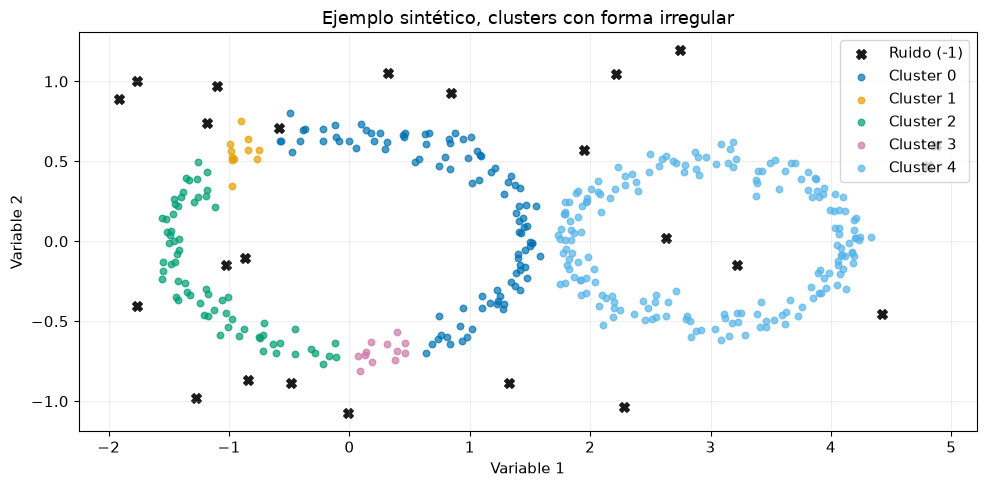

In [17]:
rng = np.random.default_rng(7)
t = np.linspace(0, 2*np.pi, 180)
X1 = np.c_[1.5*np.cos(t) + rng.normal(0, 0.07, len(t)), 0.7*np.sin(t) + rng.normal(0, 0.07, len(t))]
X2 = np.c_[1.2*np.cos(t) + 3 + rng.normal(0, 0.07, len(t)), 0.5*np.sin(t) + rng.normal(0, 0.07, len(t))]
X_demo = np.vstack([X1, X2, rng.uniform([-2, -1.2], [5, 1.2], size=(35, 2))])
etiquetas_demo = DBSCAN(eps=0.18, min_samples=6).fit_predict(X_demo)

fig, ax = plt.subplots(figsize=(10, 5))
for etiqueta in sorted(set(etiquetas_demo)):
    mascara = etiquetas_demo == etiqueta
    if etiqueta == -1:
        ax.scatter(X_demo[mascara, 0], X_demo[mascara, 1], marker="X", s=48, color="#1A1A1A", label="Ruido (-1)")
    else:
        ax.scatter(X_demo[mascara, 0], X_demo[mascara, 1], s=22, alpha=0.7, color=COLORES_CLUSTERS[etiqueta % len(COLORES_CLUSTERS)], label=f"Cluster {etiqueta}")
ax.set(title="Ejemplo sintético, clusters con forma irregular", xlabel="Variable 1", ylabel="Variable 2")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

# 21. Resumen de DBSCAN en ocho ideas

1. Es clustering no supervisado.
2. Busca regiones densas, no centroides.
3. `eps` define qué tan cerca deben estar los puntos.
4. `min_samples` define cuántos puntos se requieren para llamar densa a una zona.
5. Un núcleo cumple la densidad exigida.
6. Una frontera pertenece a un cluster sin ser núcleo.
7. El ruido recibe la etiqueta `-1`.
8. K-distance y los experimentos orientan los parámetros, no entregan una fórmula universal.

## Referencias

- [Documentación de DBSCAN en scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)
- [Documentación de NearestNeighbors en scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html)
- Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise*. KDD.